

# Extracting and visualizing subject head movement

Continuous head movement can be encoded during MEG recordings by use of
HPI coils that continuously emit sinusoidal signals. These signals can then be
extracted from the recording and used to estimate head position as a function
of time. Here we show an example of how to do this, and how to visualize
the result.

## HPI frequencies

First let's load a short bit of raw data where the subject intentionally moved
their head during the recording. Its power spectral density shows five peaks
(most clearly visible in the gradiometers) corresponding to the HPI coil
frequencies, plus other peaks related to power line interference (60 Hz and
harmonics).


In [1]:
# Authors: Eric Larson <larson.eric.d@gmail.com>
#          Richard Höchenberger <richard.hoechenberger@gmail.com>
#          Daniel McCloy <dan@mccloy.info>
#
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

Opening raw data file /home/jshen/mne_data/MNE-testing-data/SSS/test_move_anon_raw.fif...
    Read a total of 12 projection items:
        mag.fif : PCA-v1 (1 x 306)  idle
        mag.fif : PCA-v2 (1 x 306)  idle
        mag.fif : PCA-v3 (1 x 306)  idle
        mag.fif : PCA-v4 (1 x 306)  idle
        mag.fif : PCA-v5 (1 x 306)  idle
        mag.fif : PCA-v6 (1 x 306)  idle
        mag.fif : PCA-v7 (1 x 306)  idle
        grad.fif : PCA-v1 (1 x 306)  idle
        grad.fif : PCA-v2 (1 x 306)  idle
        grad.fif : PCA-v3 (1 x 306)  idle
        grad.fif : PCA-v4 (1 x 306)  idle
        Average EEG reference (1 x 60)  idle
    Range : 10800 ... 31199 =      9.000 ...    25.999 secs
Ready.
Reading 0 ... 20399  =      0.000 ...    16.999 secs...
Effective window size : 1.707 (s)
Plotting power spectral density (dB=True).


/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


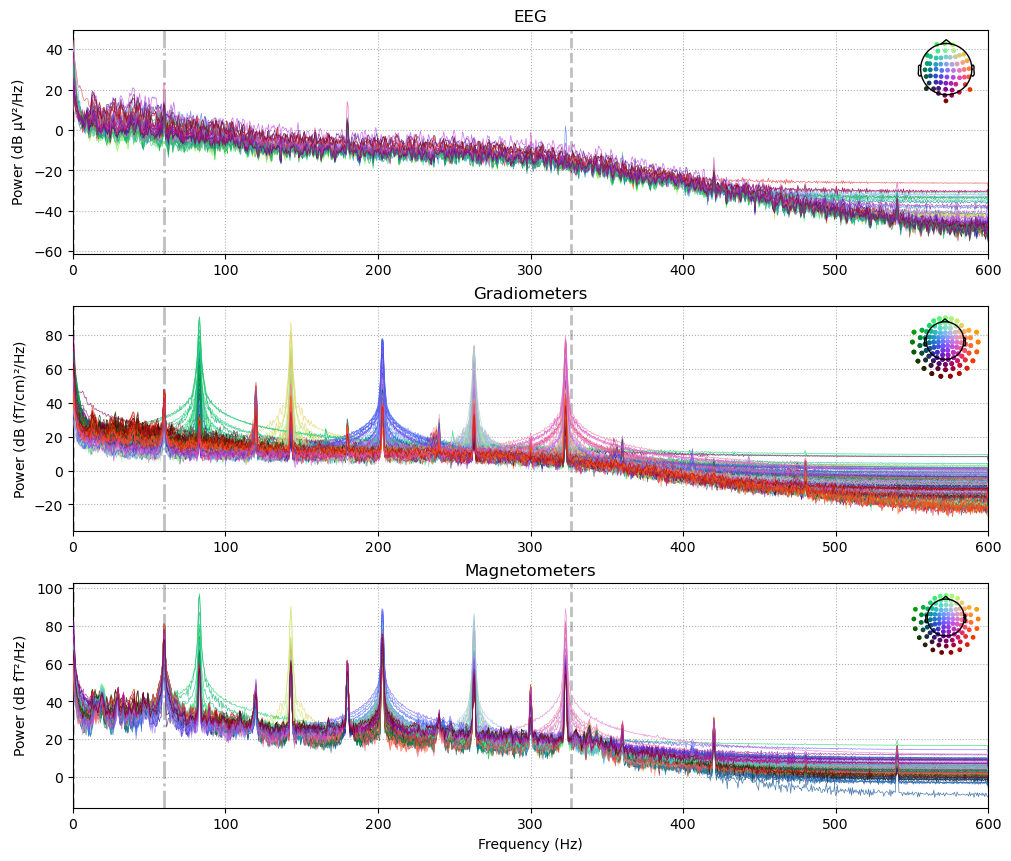

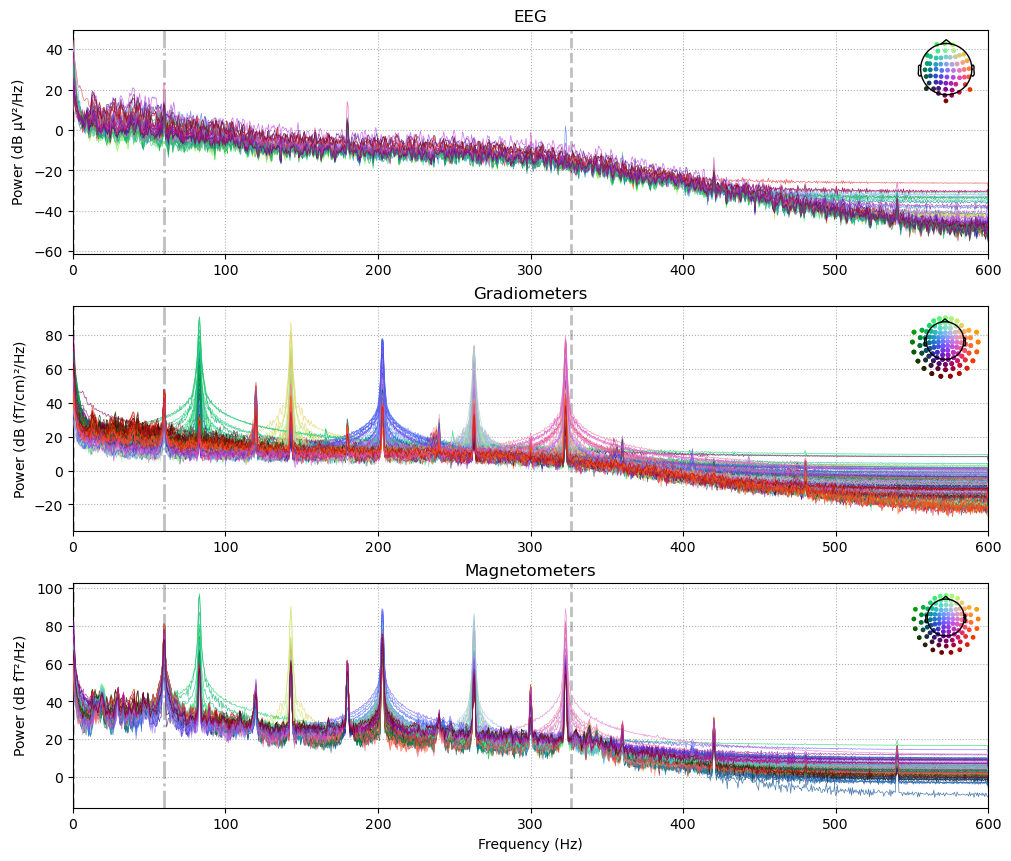

In [2]:
from os import path as op

import mne

data_path = op.join(mne.datasets.testing.data_path(verbose=True), "SSS")
fname_raw = op.join(data_path, "test_move_anon_raw.fif")
raw = mne.io.read_raw_fif(fname_raw, allow_maxshield="yes").load_data()
raw.compute_psd().plot(picks="data", exclude="bads", amplitude=False)

We can use `mne.chpi.get_chpi_info` to retrieve the coil frequencies,
the index of the channel indicating when which coil was switched on, and the
respective "event codes" associated with each coil's activity.



In [3]:
chpi_freqs, ch_idx, chpi_codes = mne.chpi.get_chpi_info(info=raw.info)
print(f"cHPI coil frequencies extracted from raw: {chpi_freqs} Hz")

Using 5 HPI coils: 83 143 203 263 323 Hz
cHPI coil frequencies extracted from raw: [ 83. 143. 203. 263. 323.] Hz


## Estimating continuous head position

First, let's extract the HPI coil amplitudes as a function of time:



In [4]:
chpi_amplitudes = mne.chpi.compute_chpi_amplitudes(raw)

Using 5 HPI coils: 83 143 203 263 323 Hz
Line interference frequencies: 60.0 120.0 180.0 240.0 300.0 360.0 Hz
Using time window: 83.3 ms
Fitting 5 HPI coil locations at up to 1696 time points (17.0 s duration)


  0%|          | cHPI amplitudes : 0/1696 [00:00<?,       ?it/s]

Second, let's compute time-varying HPI coil locations from these:



In [5]:
chpi_locs = mne.chpi.compute_chpi_locs(raw.info, chpi_amplitudes)

Computing 4385 HPI location guesses (1 cm grid in a 10.7 cm sphere)
HPIFIT: 5 coils digitized in order 5 1 4 3 2
HPI consistency of isotrak and hpifit is OK.


  0%|          | cHPI locations  : 0/1696 [00:00<?,       ?it/s]

Lastly, compute head positions from the coil locations:



In [6]:
head_pos = mne.chpi.compute_head_pos(raw.info, chpi_locs, verbose=True)

    t=9.000:     5/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.5 /      0.2 /      0.3
    t=10.000:    5/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.0 /      0.1 /      0.1
    t=11.000:    5/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.1 /      0.0 /      0.1
    t=12.000:    5/5 good HPI fits, movements [mm/s] =      0.0 /      0.0 /      0.1 /      0.0 /      0.0
    t=13.000:    5/5 good HPI fits, movements [mm/s] =      0.0 /      0.1 /      0.0 /      0.0 /      0.0
    t=14.000:    5/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.1 /      0.1 /      0.1
    t=14.580:    5/5 good HPI fits, movements [mm/s] =      5.0 /      4.8 /      6.1 /      5.5 /      4.9
    t=14.670:    5/5 good HPI fits, movements [mm/s] =     33.3 /     34.3 /     40.0 /     38.0 /     30.2
    t=14.720:    5/5 good HPI fits, movements [mm/s] =     48.9 /     47.0 /     60.3 /     59.3 /     44.5
    t=14.760:    5/5 good HP

Note that these can then be written to disk or read from disk with
:func:`mne.chpi.write_head_pos` and :func:`mne.chpi.read_head_pos`,
respectively.

## Visualizing continuous head position

We can plot as traces, which is especially useful for long recordings:



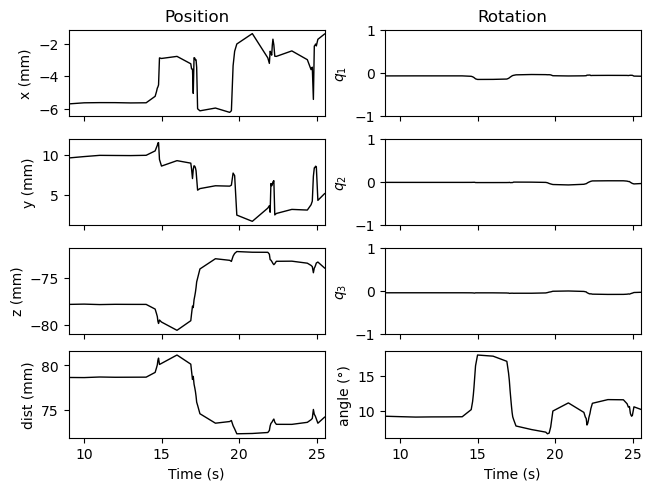

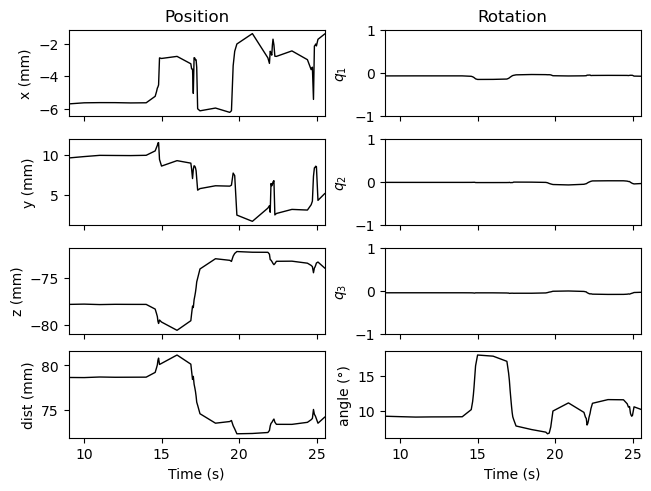

In [7]:
mne.viz.plot_head_positions(head_pos, mode="traces", totals=True)

Or we can visualize them as a continuous field (with the vectors pointing
in the head-upward direction):



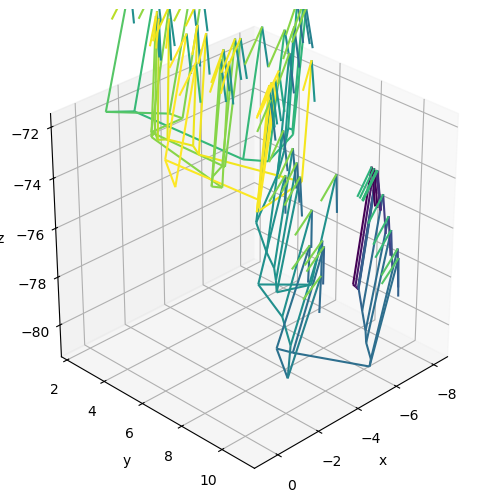

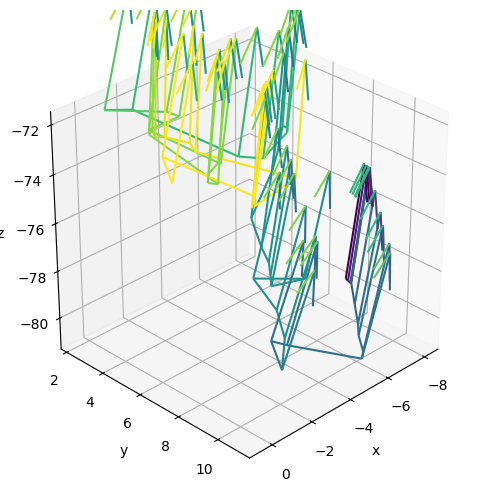

In [8]:
mne.viz.plot_head_positions(head_pos, mode="field")

These head positions can then be used with
:func:`mne.preprocessing.maxwell_filter` to compensate for movement,
or with :func:`mne.preprocessing.annotate_movement` to mark segments as
bad that deviate too much from the average head position.


## Computing SNR of the HPI signal

It is also possible to compute the SNR of the continuous HPI measurements.
This can be a useful proxy for head position along the vertical dimension,
i.e., it can indicate the distance between the HPI coils and the MEG sensors.
Using `~mne.chpi.compute_chpi_snr`, the HPI power and SNR are computed
separately for each MEG sensor type and each HPI coil (frequency), along with
the residual power for each sensor type. The results can then be visualized
with `~mne.viz.plot_chpi_snr`. Here we'll just show a few seconds, for speed:



In [9]:
raw.crop(tmin=5, tmax=10)
snr_dict = mne.chpi.compute_chpi_snr(raw)
fig = mne.viz.plot_chpi_snr(snr_dict)

Using 5 HPI coils: 83 143 203 263 323 Hz
Line interference frequencies: 60.0 120.0 180.0 240.0 300.0 360.0 Hz
Using time window: 83.3 ms
Fitting 5 HPI coil locations at up to 496 time points (5.0 s duration)


  0%|          | cHPI SNRs : 0/496 [00:00<?,       ?it/s]